# 🌿 Clusterização de Doenças em Plantas — PlantDoc
**Dataset:** 2.569 imagens · 13 espécies · 30 classes
**Abordagem:** Aprendizado **não supervisionado** — extração de características com EfficientNetB0 (extrator fixo, sem treino) + **K-Means** com **Método do Cotuvelo** para definição do número de clusters

---
### Estrutura original no Drive (formato YOLO/Roboflow):
```
plantdoc/
├── data/
│   ├── images/   ← fotos das plantas (2.313 arquivos)
│   └── labels/   ← anotações YOLO .txt (class_id x y w h)
├── test/
│   ├── images/
│   └── labels/
└── data.yaml     ← 30 nomes de classes
```
> O notebook reorganiza automaticamente as imagens em subpastas por classe (necessário apenas para sabermos a classe **real** de cada imagem e comparar com os clusters encontrados — essa informação **não é usada** para treinar o KMeans, apenas para avaliação posterior).

**Diferença em relação à versão anterior:** antes o notebook treinava uma rede (EfficientNetB0 + Transfer Learning) para **classificar** as imagens (aprendizado supervisionado, usando os rótulos). Nesta versão, seguindo a orientação do professor, o problema é tratado como **clusterização**: as imagens são agrupadas por similaridade (K-Means), sem usar os rótulos durante o agrupamento, e o **Método do Cotovelo** é usado para escolher a quantidade de clusters.

## 0. GPU e montagem do Drive

In [ ]:
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout if result.returncode == 0 else '⚠️  GPU não encontrada! Vá em: Ambiente de execução → Alterar tipo → T4 GPU')

Sat Jul 11 11:43:52 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   63C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Caminhos e classes

In [ ]:
import os

# ── Ajuste se necessário ─────────────────────────────────────────────────────
BASE_DIR = '/content/drive/MyDrive/plantdoc'
# ────────────────────────────────────────────────────────────────────────────

# Pastas originais (formato YOLO)
DATA_IMAGES_DIR  = os.path.join(BASE_DIR, 'data', 'images')
DATA_LABELS_DIR  = os.path.join(BASE_DIR, 'data', 'labels')
TEST_IMAGES_DIR  = os.path.join(BASE_DIR, 'test', 'images')
TEST_LABELS_DIR  = os.path.join(BASE_DIR, 'test', 'labels')

# Pastas de destino — imagens reorganizadas por classe (criadas no Colab, fora do Drive)
DATA_CLS_DIR = '/content/data_cls'   # imagens de data/
TEST_CLS_DIR = '/content/test_cls'   # imagens de test/

for d, nome in [
    (DATA_IMAGES_DIR, 'data/images/'),
    (DATA_LABELS_DIR, 'data/labels/'),
    (TEST_IMAGES_DIR, 'test/images/'),
    (TEST_LABELS_DIR, 'test/labels/'),
]:
    status = '✅' if os.path.exists(d) else '❌'
    n = len(os.listdir(d)) if os.path.exists(d) else 0
    print(f'{status}  {nome:20s}  {n} arquivos')

# 30 classes do data.yaml
CLASS_NAMES = [
    'Apple Scab Leaf', 'Apple leaf', 'Apple rust leaf',
    'Bell_pepper leaf spot', 'Bell_pepper leaf', 'Blueberry leaf',
    'Cherry leaf', 'Corn Gray leaf spot', 'Corn leaf blight',
    'Corn rust leaf', 'Peach leaf', 'Potato leaf early blight',
    'Potato leaf late blight', 'Potato leaf', 'Raspberry leaf',
    'Soyabean leaf', 'Soybean leaf', 'Squash Powdery mildew leaf',
    'Strawberry leaf', 'Tomato Early blight leaf',
    'Tomato Septoria leaf spot', 'Tomato leaf bacterial spot',
    'Tomato leaf late blight', 'Tomato leaf mosaic virus',
    'Tomato leaf yellow virus', 'Tomato leaf', 'Tomato mold leaf',
    'Tomato two spotted spider mites leaf', 'grape leaf black rot', 'grape leaf',
]
NUM_CLASSES = len(CLASS_NAMES)
print(f'\n{NUM_CLASSES} classes carregadas.')

✅  data/images/          2313 arquivos
✅  data/labels/          2313 arquivos
✅  test/images/          236 arquivos
✅  test/labels/          236 arquivos

30 classes carregadas.


## 2. Reorganização YOLO → pastas por classe
Cada imagem é lida junto com seu `.txt` de anotação.
A classe atribuída é a **mais frequente** na imagem (casos com múltiplos objetos).
Imagens sem anotação são ignoradas.

> Isso é feito **apenas para obtermos o rótulo real** de cada imagem (usado depois só para *avaliar* os clusters). O KMeans em si não enxerga esses rótulos.

In [ ]:
import shutil
from collections import Counter

IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

def reorganizar(images_dir, labels_dir, dest_dir, class_names, desc=''):
    '''
    Lê os arquivos de anotação YOLO e copia cada imagem para
    dest_dir/<nome_da_classe>/.

    Formato YOLO: cada linha do .txt = 'class_id x_c y_c w h'
    A classe dominante (mais frequente) é usada quando há múltiplos objetos.
    '''
    copiadas = Counter()
    sem_label = 0

    # Criar subpastas de destino
    for nome in class_names:
        os.makedirs(os.path.join(dest_dir, nome), exist_ok=True)

    for fname in os.listdir(images_dir):
        stem, ext = os.path.splitext(fname)
        if ext.lower() not in IMG_EXTS:
            continue

        label_path = os.path.join(labels_dir, stem + '.txt')
        if not os.path.exists(label_path):
            sem_label += 1
            continue

        # Ler todas as class_ids do arquivo de anotação
        class_ids = []
        with open(label_path) as f:
            for linha in f:
                linha = linha.strip()
                if linha:
                    try:
                        class_ids.append(int(linha.split()[0]))
                    except (ValueError, IndexError):
                        pass

        if not class_ids:
            sem_label += 1
            continue

        # Classe dominante
        dominant = Counter(class_ids).most_common(1)[0][0]
        class_name = class_names[dominant]

        src = os.path.join(images_dir, fname)
        dst = os.path.join(dest_dir, class_name, fname)
        shutil.copy2(src, dst)
        copiadas[class_name] += 1

    total = sum(copiadas.values())
    print(f'\n{desc}: {total} imagens organizadas em {len(copiadas)} classes  |  {sem_label} sem anotação (ignoradas)')
    return copiadas


print('Reorganizando data/ ...')
counts_data = reorganizar(DATA_IMAGES_DIR, DATA_LABELS_DIR,
                           DATA_CLS_DIR, CLASS_NAMES, desc='data/')

print('Reorganizando test/ ...')
counts_test = reorganizar(TEST_IMAGES_DIR, TEST_LABELS_DIR,
                           TEST_CLS_DIR, CLASS_NAMES, desc='test/')

Reorganizando data/ ...

data/: 2303 imagens organizadas em 29 classes  |  10 sem anotação (ignoradas)
Reorganizando test/ ...

test/: 235 imagens organizadas em 27 classes  |  1 sem anotação (ignoradas)


## 3. Imports e hiperparâmetros (Clusterização)

In [ ]:
!pip install -q kneed

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.metrics import (silhouette_score, silhouette_samples,
                              adjusted_rand_score, normalized_mutual_info_score,
                              homogeneity_completeness_v_measure)
from kneed import KneeLocator

# ── Hiperparâmetros ───────────────────────────────────────────────────────────
IMG_SIZE     = (224, 224)   # entrada da EfficientNetB0
BATCH_SIZE   = 32
SEED         = 42
K_MIN, K_MAX = 2, 40        # faixa de k testada no método do cotovelo
# ───────────────────────────────────────────────────────────────────────────────

np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'TensorFlow {tf.__version__}  |  GPU: {tf.config.list_physical_devices("GPU")}')
print(f'Classes reais (referência): {NUM_CLASSES}  |  Img: {IMG_SIZE}  |  Batch: {BATCH_SIZE}')

TensorFlow 2.20.0  |  GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Classes reais (referência): 30  |  Img: (224, 224)  |  Batch: 32


## 4. Carregamento das imagens
Usamos `data_cls/` (treino original) **e** `test_cls/` (teste original) juntos, pois em clusterização não existe divisão treino/teste — queremos agrupar **todo** o conjunto de imagens disponível. O rótulo real de cada imagem é mantido apenas para avaliação posterior dos clusters.

In [ ]:
def carregar_dataset(diretorio):
    ds = tf.keras.utils.image_dataset_from_directory(
        diretorio,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        label_mode='int',
        shuffle=False,
    )
    caminhos = ds.file_paths          # precisa ser capturado ANTES de qualquer .map/.cache
    nomes_classes = ds.class_names
    return ds, caminhos, nomes_classes

ds_data, paths_data, classes_data = carregar_dataset(DATA_CLS_DIR)
ds_test, paths_test, classes_test = carregar_dataset(TEST_CLS_DIR)

assert classes_data == classes_test, 'As pastas data_cls/ e test_cls/ não têm as mesmas classes/índices!'
CLASS_NAMES_ORDENADAS = classes_data   # ordem alfabética usada pelo Keras

# Junta os dois datasets em um só fluxo de inferência
ds_full = ds_data.concatenate(ds_test)
all_paths = paths_data + paths_test

print(f'Total de imagens (data + test): {len(all_paths)}')
print(f'Classes detectadas: {len(CLASS_NAMES_ORDENADAS)}')

Found 2303 files belonging to 30 classes.
Found 235 files belonging to 30 classes.
Total de imagens (data + test): 2538
Classes detectadas: 30


## 5. Extração de características com EfficientNetB0 (extrator fixo)
A EfficientNetB0 pré-treinada na ImageNet é usada **apenas como extrator de características** (sem cabeça de classificação, `include_top=False`, `pooling='avg'`). Nenhuma camada é treinada — os pesos ficam congelados. Cada imagem vira um vetor de 1280 números que resume seu conteúdo visual, e é esse vetor que será agrupado pelo K-Means.

In [ ]:
extractor = EfficientNetB0(
    include_top=False,
    weights='imagenet',
    pooling='avg',           # Global Average Pooling → vetor (1280,) por imagem
    input_shape=(*IMG_SIZE, 3),
)
extractor.trainable = False

print(f'Extrator: EfficientNetB0  |  Dimensão do vetor de características: {extractor.output_shape[-1]}')

Extrator: EfficientNetB0  |  Dimensão do vetor de características: 1280


In [ ]:
features_list, labels_list = [], []

for imgs, lbls in ds_full:
    imgs_proc = preprocess_input(imgs)          # normalização esperada pela EfficientNet
    feats = extractor(imgs_proc, training=False)
    features_list.append(feats.numpy())
    labels_list.append(lbls.numpy())

X = np.concatenate(features_list, axis=0)        # (N, 1280) — características
y_true = np.concatenate(labels_list, axis=0)     # (N,)      — classe real (só para avaliação)

print(f'Matriz de características: {X.shape}')
print(f'Rótulos reais (referência): {y_true.shape}')
assert X.shape[0] == len(all_paths) == y_true.shape[0]

Matriz de características: (2538, 1280)
Rótulos reais (referência): (2538,)


## 6. Pré-processamento das características (padronização + PCA)
As características são padronizadas (média 0, desvio 1) e depois reduzidas com **PCA**, o que:
- diminui o ruído e a redundância entre as 1280 dimensões da EfficientNetB0;
- acelera o K-Means e o cálculo do cotovelo/silhueta;
- evita a "maldição da dimensionalidade" (em espaços muito grandes, todas as distâncias ficam parecidas e o K-Means perde eficácia).

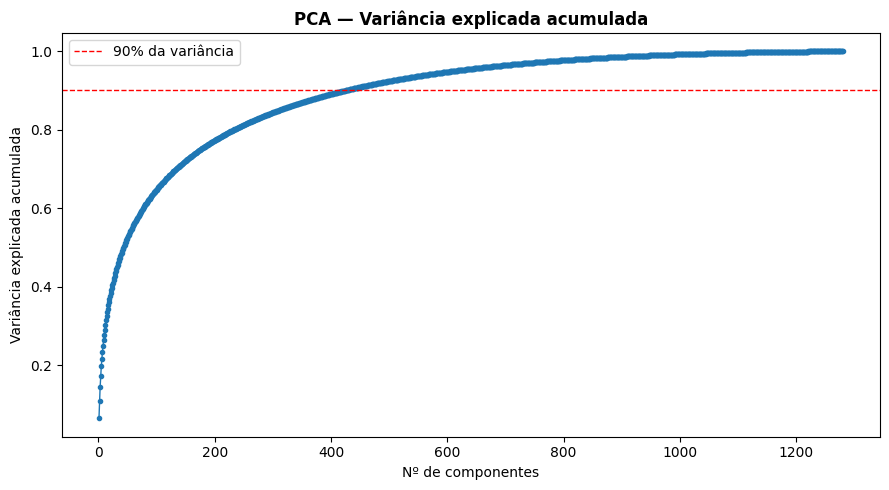

Componentes necessários para 90% da variância: 425
Características reduzidas: (2538, 425)


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA exploratório — quantas componentes explicam a variância?
pca_full = PCA(random_state=SEED).fit(X_scaled)
var_acumulada = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(9, 5))
plt.plot(range(1, len(var_acumulada) + 1), var_acumulada, marker='.', linewidth=1)
plt.axhline(0.90, color='red', linestyle='--', linewidth=1, label='90% da variância')
plt.xlabel('Nº de componentes')
plt.ylabel('Variância explicada acumulada')
plt.title('PCA — Variância explicada acumulada', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

N_COMPONENTS = int(np.argmax(var_acumulada >= 0.90) + 1)
print(f'Componentes necessários para 90% da variância: {N_COMPONENTS}')

pca = PCA(n_components=N_COMPONENTS, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)
print(f'Características reduzidas: {X_pca.shape}')

## 7. Método do Cotovelo (Elbow Method)
Para cada valor de *k* (nº de clusters) entre 2 e 20, treinamos um K-Means e registramos:
- **Inércia (WCSS)** — soma das distâncias quadráticas de cada ponto ao centro do seu cluster. Quanto menor, mais compactos os clusters — mas ela sempre cai à medida que *k* aumenta, então buscamos o "cotovelo" da curva (ponto de retorno decrescente).
- **Silhueta** — mede o quão bem cada ponto se encaixa no próprio cluster comparado aos demais (varia de -1 a 1; quanto maior, melhor a separação).

In [ ]:
inercias, silhuetas = [], []
ks = list(range(K_MIN, K_MAX + 1))

for k in ks:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels_k = km.fit_predict(X_pca)
    inercias.append(km.inertia_)
    sil = silhouette_score(X_pca, labels_k, sample_size=min(2000, X_pca.shape[0]), random_state=SEED)
    silhuetas.append(sil)
    print(f'k={k:2d}  |  inércia={km.inertia_:12.1f}  |  silhueta={sil:.4f}')

k= 2  |  inércia=   2781197.8  |  silhueta=0.1182
k= 3  |  inércia=   2678242.0  |  silhueta=0.0948
k= 4  |  inércia=   2602311.8  |  silhueta=0.0565
k= 5  |  inércia=   2546724.5  |  silhueta=0.0575
k= 6  |  inércia=   2507925.2  |  silhueta=0.0466
k= 7  |  inércia=   2475424.8  |  silhueta=0.0451
k= 8  |  inércia=   2442671.8  |  silhueta=0.0501
k= 9  |  inércia=   2416540.2  |  silhueta=-0.0043
k=10  |  inércia=   2397423.5  |  silhueta=-0.0159
k=11  |  inércia=   2376712.5  |  silhueta=-0.0047
k=12  |  inércia=   2360766.2  |  silhueta=-0.0119
k=13  |  inércia=   2338401.0  |  silhueta=-0.0116
k=14  |  inércia=   2323935.2  |  silhueta=-0.0106
k=15  |  inércia=   2313972.2  |  silhueta=-0.0054
k=16  |  inércia=   2296680.0  |  silhueta=-0.0094
k=17  |  inércia=   2282229.5  |  silhueta=-0.0037
k=18  |  inércia=   2272172.2  |  silhueta=-0.0116
k=19  |  inércia=   2256818.2  |  silhueta=-0.0079
k=20  |  inércia=   2248949.8  |  silhueta=-0.0027
k=21  |  inércia=   2231496.2  |  silh

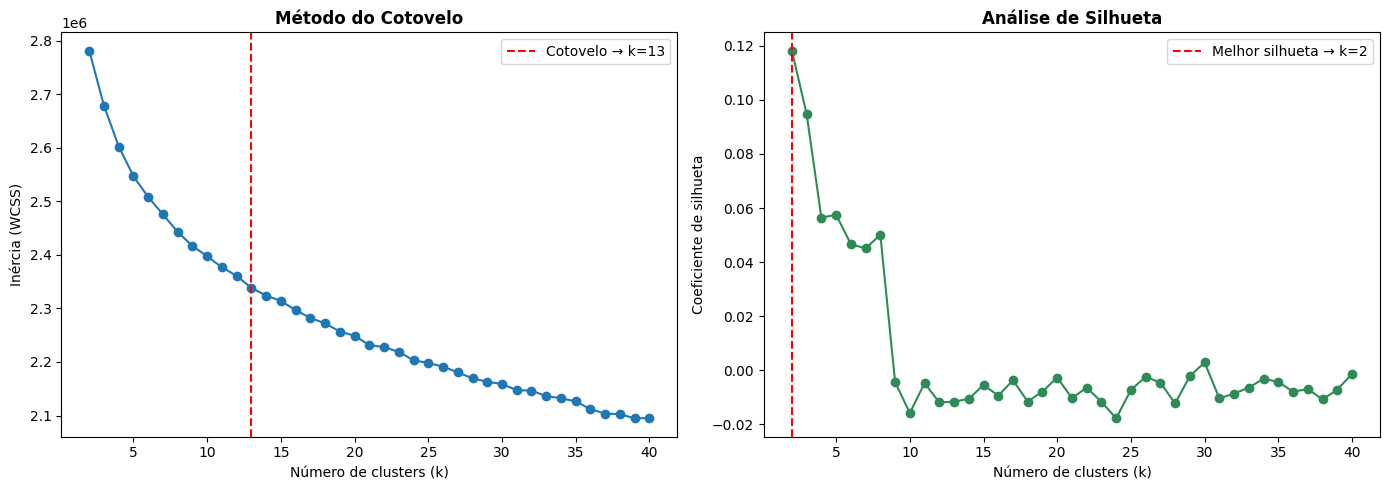


k sugerido pelo cotovelo   : 13
k sugerido pela silhueta   : 2
k de referência (nº classes reais) : 30


In [ ]:
# Detecção automática do cotovelo
knee = KneeLocator(ks, inercias, curve='convex', direction='decreasing')
K_COTOVELO = knee.knee if knee.knee is not None else ks[len(ks)//2]
K_SILHUETA = ks[int(np.argmax(silhuetas))]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(ks, inercias, marker='o')
axes[0].axvline(K_COTOVELO, color='red', linestyle='--', label=f'Cotovelo → k={K_COTOVELO}')
axes[0].set_xlabel('Número de clusters (k)')
axes[0].set_ylabel('Inércia (WCSS)')
axes[0].set_title('Método do Cotovelo', fontweight='bold')
axes[0].legend()

axes[1].plot(ks, silhuetas, marker='o', color='seagreen')
axes[1].axvline(K_SILHUETA, color='red', linestyle='--', label=f'Melhor silhueta → k={K_SILHUETA}')
axes[1].set_xlabel('Número de clusters (k)')
axes[1].set_ylabel('Coeficiente de silhueta')
axes[1].set_title('Análise de Silhueta', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'\nk sugerido pelo cotovelo   : {K_COTOVELO}')
print(f'k sugerido pela silhueta   : {K_SILHUETA}')
print(f'k de referência (nº classes reais) : {NUM_CLASSES}')

## 8. Ajuste final do K-Means
Usamos o *k* indicado pelo **método do cotovelo** para o agrupamento final. (Se quiser comparar diretamente com as classes reais, basta trocar `K_FINAL` por `NUM_CLASSES` na célula abaixo.)

In [ ]:
K_FINAL = K_COTOVELO   # ← troque para NUM_CLASSES se quiser comparar 1-a-1 com as classes reais

kmeans_final = KMeans(n_clusters=K_FINAL, random_state=SEED, n_init=10)
clusters = kmeans_final.fit_predict(X_pca)

sil_final = silhouette_score(X_pca, clusters, sample_size=min(3000, X_pca.shape[0]), random_state=SEED)

print(f'K-Means final ajustado com k = {K_FINAL}')
print(f'Silhueta média: {sil_final:.4f}')
print('\nImagens por cluster:')
print(pd.Series(clusters).value_counts().sort_index())

K-Means final ajustado com k = 13
Silhueta média: -0.0104

Imagens por cluster:
0     160
1     418
2     195
3     209
4     274
5     140
6     257
7     286
8      81
9     149
10     76
11    167
12    126
Name: count, dtype: int64


## 9. Visualização dos clusters (PCA 2D)

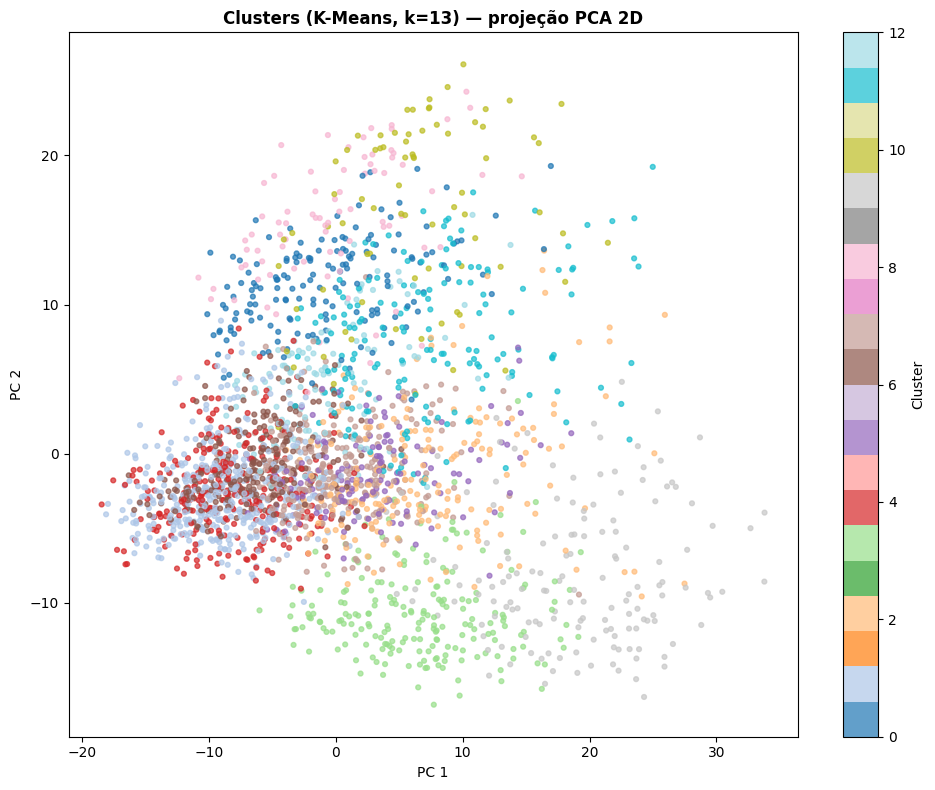

In [ ]:
pca_2d = PCA(n_components=2, random_state=SEED).fit_transform(X_pca)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(pca_2d[:, 0], pca_2d[:, 1], c=clusters, cmap='tab20', s=12, alpha=0.7)
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.title(f'Clusters (K-Means, k={K_FINAL}) — projeção PCA 2D', fontweight='bold')
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.show()

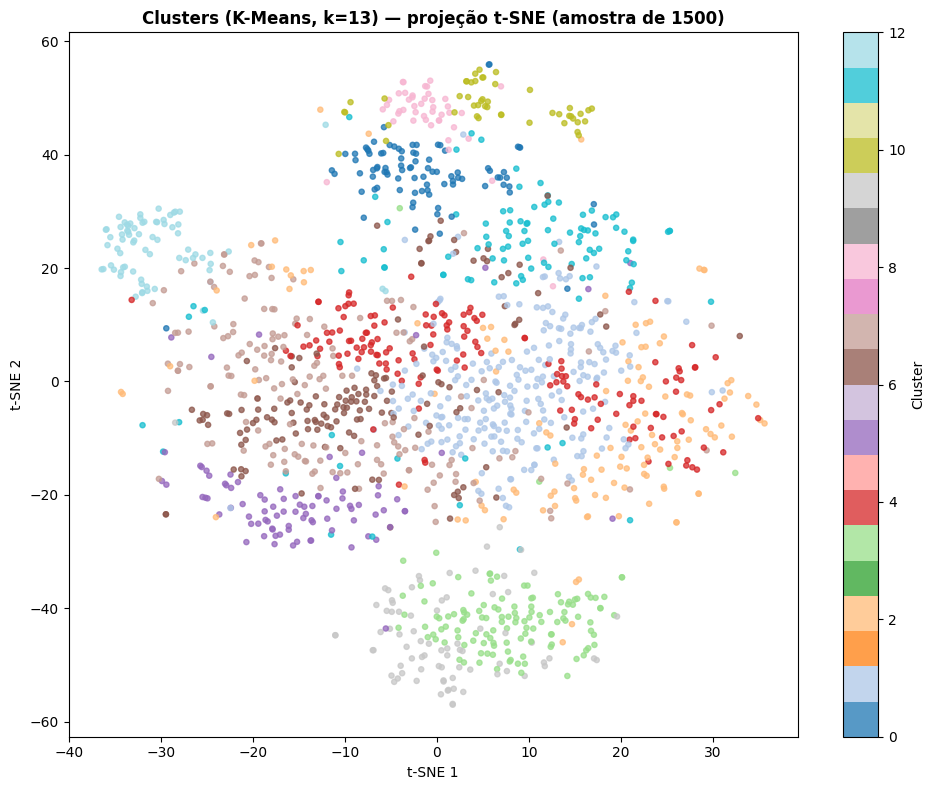

In [ ]:
# t-SNE (mais lento, mas separa melhor grupos não-lineares) — usa amostra para agilizar
N_TSNE = min(1500, X_pca.shape[0])
idx_sample = np.random.RandomState(SEED).choice(X_pca.shape[0], N_TSNE, replace=False)

tsne = TSNE(n_components=2, random_state=SEED, init='pca', perplexity=30)
X_tsne = tsne.fit_transform(X_pca[idx_sample])

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=clusters[idx_sample], cmap='tab20', s=14, alpha=0.75)
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title(f'Clusters (K-Means, k={K_FINAL}) — projeção t-SNE (amostra de {N_TSNE})', fontweight='bold')
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.show()

## 10. Comparação com as classes reais
Como *temos* o rótulo verdadeiro de cada imagem (obtido na reorganização YOLO), podemos avaliar **quão bem os clusters encontrados pelo K-Means coincidem com as classes reais** — mesmo sem usar esses rótulos durante o treinamento do K-Means.

Métricas usadas:
- **ARI (Adjusted Rand Index):** concordância entre cluster e classe real, ajustada ao acaso (1 = concordância perfeita, 0 = aleatório).
- **NMI (Normalized Mutual Information):** quanta informação um agrupamento dá sobre o outro (0 a 1).
- **Homogeneidade:** cada cluster contém majoritariamente uma única classe real.
- **Completude:** todos os membros de uma classe real caem no mesmo cluster.
- **V-measure:** média harmônica entre homogeneidade e completude.

In [ ]:
ari = adjusted_rand_score(y_true, clusters)
nmi = normalized_mutual_info_score(y_true, clusters)
homog, complet, vmeasure = homogeneity_completeness_v_measure(y_true, clusters)

print('=== COMPARAÇÃO CLUSTERS x CLASSES REAIS ===')
print(f'Adjusted Rand Index (ARI)      : {ari:.4f}')
print(f'Normalized Mutual Info (NMI)   : {nmi:.4f}')
print(f'Homogeneidade                  : {homog:.4f}')
print(f'Completude                     : {complet:.4f}')
print(f'V-measure                      : {vmeasure:.4f}')

=== COMPARAÇÃO CLUSTERS x CLASSES REAIS ===
Adjusted Rand Index (ARI)      : 0.1165
Normalized Mutual Info (NMI)   : 0.2947
Homogeneidade                  : 0.2589
Completude                     : 0.3420
V-measure                      : 0.2947


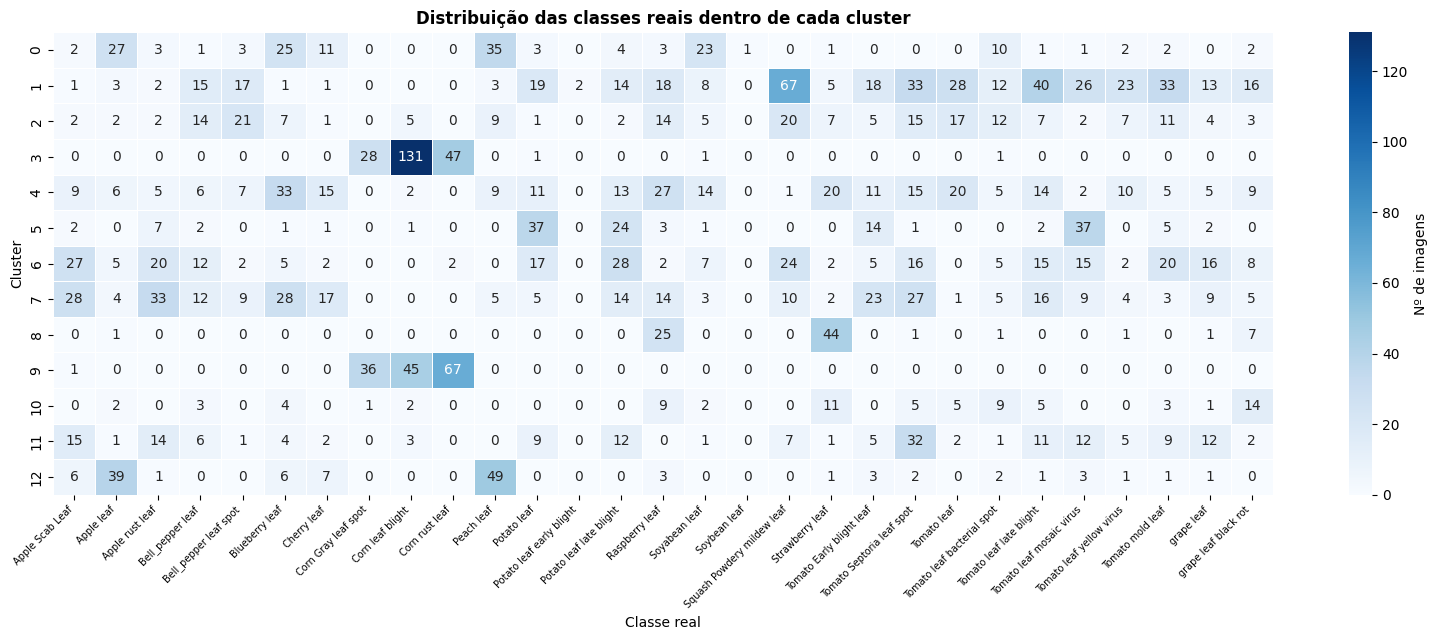

In [ ]:
nomes_reais = [CLASS_NAMES_ORDENADAS[i] for i in y_true]
tabela = pd.crosstab(pd.Series(clusters, name='Cluster'), pd.Series(nomes_reais, name='Classe real'))

plt.figure(figsize=(16, max(6, K_FINAL * 0.5)))
sns.heatmap(tabela, annot=True, fmt='d', cmap='Blues', linewidths=0.4, cbar_kws={'label': 'Nº de imagens'})
plt.title('Distribuição das classes reais dentro de cada cluster', fontweight='bold')
plt.xlabel('Classe real')
plt.ylabel('Cluster')
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.tight_layout()
plt.show()

## 11. Pureza de cada cluster (classe real dominante)

In [ ]:
linhas = []
for c in range(K_FINAL):
    idx = np.where(clusters == c)[0]
    if len(idx) == 0:
        continue
    classes_do_cluster = pd.Series([nomes_reais[i] for i in idx])
    dominante = classes_do_cluster.value_counts().idxmax()
    freq = classes_do_cluster.value_counts().max()
    pureza = freq / len(idx)
    linhas.append({'Cluster': c, 'Nº imagens': len(idx),
                    'Classe dominante': dominante, 'Pureza': round(pureza, 3)})

df_pureza = pd.DataFrame(linhas).sort_values('Pureza', ascending=False)
df_pureza

,Cluster,Nº imagens,Classe dominante,Pureza
3,3,209,Corn leaf blight,0.627
8,8,81,Strawberry leaf,0.543
9,9,149,Corn rust leaf,0.450
12,12,126,Peach leaf,0.389
5,5,140,Potato leaf,0.264
0,0,160,Peach leaf,0.219
11,11,167,Tomato Septoria leaf spot,0.192
10,10,76,grape leaf black rot,0.184
1,1,418,Squash Powdery mildew leaf,0.160
4,4,274,Blueberry leaf,0.120


## 12. Amostras de imagens por cluster

In [ ]:
def mostrar_amostras_cluster(cluster_id, n=6):
    idx = np.where(clusters == cluster_id)[0]
    if len(idx) == 0:
        print(f'Cluster {cluster_id} está vazio.')
        return
    escolhidos = np.random.RandomState(SEED).choice(idx, size=min(n, len(idx)), replace=False)

    plt.figure(figsize=(15, 3))
    for i, ix in enumerate(escolhidos):
        img = tf.keras.utils.load_img(all_paths[ix], target_size=IMG_SIZE)
        plt.subplot(1, len(escolhidos), i + 1)
        plt.imshow(img)
        plt.title(nomes_reais[ix], fontsize=7, wrap=True)
        plt.axis('off')
    plt.suptitle(f'Cluster {cluster_id}  ({len(idx)} imagens)', fontweight='bold')
    plt.tight_layout()
    plt.show()

# Mostra amostras dos primeiros clusters (ajuste o range para ver todos)
for c in range(min(5, K_FINAL)):
    mostrar_amostras_cluster(c)

Output hidden; open in https://colab.research.google.com to view.

## 13. Salvando resultados no Drive

In [ ]:
import joblib

RESULTS_DIR = os.path.join(BASE_DIR, 'clusterizacao_resultados')
os.makedirs(RESULTS_DIR, exist_ok=True)

# Tabela com caminho da imagem, classe real e cluster atribuído
df_resultado = pd.DataFrame({
    'caminho': all_paths,
    'classe_real': nomes_reais,
    'cluster': clusters,
})
csv_path = os.path.join(RESULTS_DIR, 'clusters_atribuidos.csv')
df_resultado.to_csv(csv_path, index=False)

joblib.dump(scaler, os.path.join(RESULTS_DIR, 'scaler.joblib'))
joblib.dump(pca, os.path.join(RESULTS_DIR, 'pca.joblib'))
joblib.dump(kmeans_final, os.path.join(RESULTS_DIR, 'kmeans_final.joblib'))

print(f'✅ Resultados salvos em: {RESULTS_DIR}')
print(f'   - {csv_path}')
print('   - scaler.joblib / pca.joblib / kmeans_final.joblib')

✅ Resultados salvos em: /content/drive/MyDrive/plantdoc/clusterizacao_resultados
   - /content/drive/MyDrive/plantdoc/clusterizacao_resultados/clusters_atribuidos.csv
   - scaler.joblib / pca.joblib / kmeans_final.joblib


## 14. Resumo final

In [ ]:
print('=' * 60)
print('     RESUMO FINAL — Clusterização PlantDoc (K-Means)')
print('=' * 60)
print(f'  Total de imagens              : {X.shape[0]}')
print(f'  Nº de classes reais           : {NUM_CLASSES}')
print(f'  Extrator de características   : EfficientNetB0 (ImageNet, sem treino)')
print(f'  Dimensão original das feats.  : {X.shape[1]}')
print(f'  Componentes PCA (90% var.)    : {N_COMPONENTS}')
print(f'  k sugerido — cotovelo         : {K_COTOVELO}')
print(f'  k sugerido — silhueta         : {K_SILHUETA}')
print(f'  k utilizado no K-Means final  : {K_FINAL}')
print(f'  Silhueta do modelo final      : {sil_final:.4f}')
print(f'  Adjusted Rand Index (ARI)     : {ari:.4f}')
print(f'  Normalized Mutual Info (NMI)  : {nmi:.4f}')
print(f'  Homogeneidade / Completude    : {homog:.4f} / {complet:.4f}')
print('=' * 60)

     RESUMO FINAL — Clusterização PlantDoc (K-Means)
  Total de imagens              : 2538
  Nº de classes reais           : 30
  Extrator de características   : EfficientNetB0 (ImageNet, sem treino)
  Dimensão original das feats.  : 1280
  Componentes PCA (90% var.)    : 425
  k sugerido — cotovelo         : 13
  k sugerido — silhueta         : 2
  k utilizado no K-Means final  : 13
  Silhueta do modelo final      : -0.0104
  Adjusted Rand Index (ARI)     : 0.1165
  Normalized Mutual Info (NMI)  : 0.2947
  Homogeneidade / Completude    : 0.2589 / 0.3420
